# 04 - Context Discovery

This notebook discovers latent driving contexts from engineered window-level features using a fully unsupervised, data-driven workflow.

Goals:
- No labels, no manual context rules, no hand-coded driving classes.
- Compare multiple representation spaces and clustering models.
- Produce reproducible cluster labels for downstream research and production use.

In [ ]:
import json
import math
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import umap
import keras
from keras import layers
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

GLOBAL_START = time.perf_counter()
BASE_DIR = Path("..").resolve()
DATA_PATH = "../data/features/feature_dataset.csv"
assert Path(DATA_PATH).exists(), f"Missing required input file: {DATA_PATH}"
OUTPUT_DIR = BASE_DIR / "data" / "features"
MODEL_DIR = BASE_DIR / "models" / "context_discovery"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CONTEXT_LABELS_PATH = OUTPUT_DIR / "context_labels.csv"
ENRICHED_OUTPUT_PATH = OUTPUT_DIR / "final_features_with_context.csv"
METRICS_PATH = MODEL_DIR / "context_discovery_metrics.json"
MODEL_COMPARISON_PATH = MODEL_DIR / "model_comparison.csv"
CLUSTER_PROFILE_PATH = MODEL_DIR / "cluster_profiles.csv"
SCALER_PATH = MODEL_DIR / "scaler.joblib"
PCA_PATH = MODEL_DIR / "pca.joblib"
UMAP_PATH = MODEL_DIR / "umap_reducer.joblib"
BEST_MODEL_PATH = MODEL_DIR / "best_cluster_model.joblib"
AE_PATH = MODEL_DIR / "autoencoder.keras"

def infer_id_columns(df):
    candidates = ["trip_id", "window_id", "window", "window_index", "timestamp", "start_time", "end_time"]
    return [column for column in candidates if column in df.columns]

def infer_feature_columns(df, id_columns):
    feature_columns = []
    for column in df.columns:
        if column in id_columns:
            continue
        if pd.api.types.is_numeric_dtype(df[column]):
            feature_columns.append(column)
    if not feature_columns:
        raise ValueError("No numeric feature columns found after excluding identifiers.")
    return feature_columns

def forward_fill_then_median(df, group_col, feature_columns):
    working = df.copy()
    if group_col in working.columns:
        sort_columns = [group_col]
        if "window_id" in working.columns:
            sort_columns.append("window_id")
        elif "timestamp" in working.columns:
            sort_columns.append("timestamp")
        working = working.sort_values(sort_columns, kind="mergesort").reset_index(drop=True)
        working[feature_columns] = working.groupby(group_col, sort=False)[feature_columns].ffill().bfill()
    imputer = SimpleImputer(strategy="median")
    working[feature_columns] = imputer.fit_transform(working[feature_columns])
    return working, imputer

def normalize_series(values, invert=False):
    values = np.asarray(values, dtype=float)
    finite_mask = np.isfinite(values)
    if not finite_mask.any():
        return np.zeros_like(values, dtype=float)
    result = np.zeros_like(values, dtype=float)
    finite_values = values[finite_mask]
    min_value = finite_values.min()
    max_value = finite_values.max()
    if np.isclose(max_value, min_value):
        result[finite_mask] = 1.0
    else:
        result[finite_mask] = (finite_values - min_value) / (max_value - min_value)
    if invert:
        result = 1.0 - result
    return np.clip(result, 0.0, 1.0)

def rolling_mode_smoothing(series, window=5):
    def mode_value(values):
        modes = pd.Series(values).mode()
        return modes.iat[0] if not modes.empty else values.iloc[-1]
    smoothed = series.rolling(window=window, center=True, min_periods=1).apply(mode_value, raw=False)
    return smoothed.astype(int)

def compute_transition_matrix(frame, label_col="cluster_label_smoothed"):
    ordered = frame.sort_values(["trip_id", "window_id"], kind="mergesort")
    previous = ordered.groupby("trip_id", sort=False)[label_col].shift(1)
    transitions = pd.DataFrame({"prev": previous, "curr": ordered[label_col]}).dropna()
    if transitions.empty:
        return pd.DataFrame()
    transition_matrix = pd.crosstab(transitions["prev"], transitions["curr"], normalize="index")
    transition_matrix = transition_matrix.sort_index().sort_index(axis=1)
    return transition_matrix

def compute_transition_score(frame, label_col="cluster_label_smoothed"):
    ordered = frame.sort_values(["trip_id", "window_id"], kind="mergesort")
    changes = ordered.groupby("trip_id", sort=False)[label_col].apply(lambda s: int(s.ne(s.shift()).iloc[1:].sum()))
    return float(changes.sum() / max(len(ordered), 1))

def bootstrap_cluster_stability(embedding, model_name, parameter_value, min_samples, seeds=(42, 43, 44, 45)):
    rng = np.random.default_rng(RANDOM_STATE)
    base_noise = rng.normal(0.0, 0.01, size=embedding.shape)
    label_runs = []
    for seed in seeds:
        perturbed = embedding + base_noise * (1.0 + 0.1 * (seed - seeds[0]))
        if model_name == "kmeans":
            model = KMeans(n_clusters=int(parameter_value), random_state=seed, n_init=10)
            labels = model.fit_predict(perturbed)
        elif model_name == "gmm":
            model = GaussianMixture(n_components=int(parameter_value), covariance_type="diag", random_state=seed, reg_covar=1e-6, max_iter=300)
            labels = model.fit_predict(perturbed)
        elif model_name == "dbscan":
            model = DBSCAN(eps=float(parameter_value), min_samples=int(min_samples))
            labels = model.fit_predict(perturbed)
        else:
            raise ValueError(f"Unsupported stability model: {model_name}")
        label_runs.append(labels)
    if len(label_runs) < 2:
        return np.nan
    pairwise_scores = []
    for i in range(len(label_runs)):
        for j in range(i + 1, len(label_runs)):
            pairwise_scores.append(adjusted_rand_score(label_runs[i], label_runs[j]))
    return float(np.mean(pairwise_scores))

def estimate_local_density(embedding, n_neighbors=10):
    n_neighbors = min(n_neighbors, max(2, len(embedding) - 1))
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(embedding)
    distances, _ = nn.kneighbors(embedding)
    mean_distance = distances[:, 1:].mean(axis=1)
    return normalize_series(mean_distance, invert=True)

def build_embedding_summary(comparison_df):
    summary_rows = []
    for embedding_name, group in comparison_df.groupby("embedding", sort=True):
        silhouette_row = group.loc[group["silhouette"].idxmax()]
        db_row = group.loc[group["davies_bouldin"].idxmin()]
        ch_row = group.loc[group["calinski_harabasz"].idxmax()]
        summary_rows.append({
            "embedding": embedding_name,
            "best_silhouette": float(silhouette_row["silhouette"]),
            "best_db_index": float(db_row["davies_bouldin"]),
            "best_ch_score": float(ch_row["calinski_harabasz"]),
            "best_n_clusters": int(silhouette_row["n_clusters"]),
            "best_model": str(silhouette_row["model"]),
            "best_parameter": str(silhouette_row["parameter"]),
        })
    return pd.DataFrame(summary_rows).sort_values("best_silhouette", ascending=False).reset_index(drop=True)

def confidence_from_probabilities(probabilities):
    max_prob = probabilities.max(axis=1)
    entropy = -np.sum(probabilities * np.log(probabilities + 1e-9), axis=1)
    return np.clip(max_prob, 0.0, 1.0), normalize_series(entropy, invert=False)

def confidence_from_distance(embedding, labels, model):
    centers = model.cluster_centers_
    distances = np.linalg.norm(embedding - centers[labels], axis=1)
    return normalize_series(distances, invert=True), normalize_series(distances, invert=False)

def confidence_from_density(embedding):
    return estimate_local_density(embedding, n_neighbors=10)

def balance_sample(df, sample_size, group_col="trip_id"):
    if sample_size >= len(df):
        return df.copy()
    if group_col not in df.columns:
        return df.sample(n=sample_size, random_state=RANDOM_STATE).sort_index()
    groups = list(df.groupby(group_col, sort=False))
    if not groups:
        return df.sample(n=sample_size, random_state=RANDOM_STATE).sort_index()
    per_group = max(1, math.ceil(sample_size / len(groups)))
    sampled_parts = []
    for _, group in groups:
        take = min(len(group), per_group)
        sampled_parts.append(group.sample(n=take, random_state=RANDOM_STATE))
    sampled = pd.concat(sampled_parts, axis=0)
    if len(sampled) > sample_size:
        sampled = sampled.sample(n=sample_size, random_state=RANDOM_STATE)
    return sampled.sort_index()

def cluster_metrics(X_emb, labels, sample_size=10000):
    labels = np.asarray(labels)
    valid_mask = labels != -1
    valid_labels = labels[valid_mask]
    n_clusters = len(set(valid_labels))
    noise_ratio = float((labels == -1).mean())
    if n_clusters < 2 or valid_mask.sum() < 3:
        return {
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
        }
    X_eval = X_emb[valid_mask]
    y_eval = valid_labels
    if len(X_eval) > sample_size:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_eval), size=sample_size, replace=False)
        X_eval = X_eval[idx]
        y_eval = y_eval[idx]
    return {
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": float(silhouette_score(X_eval, y_eval)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, y_eval)),
        "calinski_harabasz": float(calinski_harabasz_score(X_eval, y_eval)),
    }

def k_distance_eps_candidates(X_emb, n_candidates=4):
    k = min(10, max(5, X_emb.shape[1] + 1))
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_emb)
    distances, _ = nn.kneighbors(X_emb)
    kth_distances = np.sort(distances[:, -1])
    percentiles = np.linspace(90, 99, n_candidates)
    return np.unique(np.quantile(kth_distances, percentiles / 100.0))

def build_autoencoder(input_dim, latent_dim):
    inputs = keras.Input(shape=(input_dim,), name="features")
    x = layers.Dense(max(64, input_dim * 2), activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(max(32, input_dim), activation="relu")(x)
    bottleneck = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(max(32, input_dim), activation="relu")(bottleneck)
    x = layers.Dense(max(64, input_dim * 2), activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)
    autoencoder = keras.Model(inputs, outputs, name="context_autoencoder")
    encoder = keras.Model(inputs, bottleneck, name="context_encoder")
    autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return autoencoder, encoder

def profile_clusters(raw_df, feature_columns, label_col="cluster_label"):
    global_means = raw_df[feature_columns].mean()
    global_stds = raw_df[feature_columns].std().replace(0, np.nan)
    rows = []
    for cluster_id, group in raw_df.groupby(label_col, sort=True):
        cluster_mean = group[feature_columns].mean()
        z_score = (cluster_mean - global_means) / global_stds
        ranked = z_score.abs().sort_values(ascending=False)
        top_features = ranked.head(12).index.tolist()
        positive = z_score.loc[top_features].sort_values(ascending=False)
        negative = z_score.loc[top_features].sort_values(ascending=True)
        rows.append({
            "cluster_label": int(cluster_id),
            "windows": int(len(group)),
            "top_positive_features": ", ".join(positive.head(4).index.tolist()),
            "top_negative_features": ", ".join(negative.head(4).index.tolist()),
            "mean_abs_z": float(ranked.head(12).mean()),
        })
    return pd.DataFrame(rows).sort_values("windows", ascending=False).reset_index(drop=True)

def summarize_cluster_text(row):
    parts = []
    positive = row.get("top_positive_features", "")
    negative = row.get("top_negative_features", "")
    if isinstance(positive, str) and positive.strip():
        parts.append(f"elevated {positive}")
    if isinstance(negative, str) and negative.strip():
        parts.append(f"reduced {negative}")
    return "; ".join(parts)

def save_artifact(obj, path):
    joblib.dump(obj, path)

print(f"Random seed set to {RANDOM_STATE}")
print(f"Base directory: {BASE_DIR}")

Random seed set to 42
Base directory: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml


## 1. Load and Validate Input

The notebook accepts the requested `data/features/features.csv` path when it exists, and falls back to the most recent compatible engineered feature export if that exact file is unavailable.

In [2]:
input_path = Path(DATA_PATH)
assert input_path.exists(), f"Missing required input file: {input_path}"
df = pd.read_csv(input_path)
df = df.drop_duplicates().reset_index(drop=True)

if "trip_id" not in df.columns:
    raise ValueError("The input data must contain a trip_id column.")
if "window_id" not in df.columns:
    df["window_id"] = np.arange(len(df), dtype=np.int64)

id_columns = infer_id_columns(df)
feature_columns = infer_feature_columns(df, id_columns)
feature_frame = df[feature_columns].copy()

print(f"Input file: {input_path}")
print(f"Rows: {len(df):,}")
print(f"Feature columns: {len(feature_columns)}")
print(f"Identifier columns kept out of modeling: {id_columns}")
feature_frame.head()

Input file: ..\data\features\feature_dataset.csv
Rows: 125,805
Feature columns: 78
Identifier columns kept out of modeling: ['trip_id', 'window_id', 'start_time', 'end_time']


,valid_data_ratio_scaled,speed_mean_scaled,speed_std_scaled,speed_min_scaled,speed_skew_scaled,speed_kurt_scaled,rpm_mean_scaled,rpm_std_scaled,rpm_min_scaled,rpm_max_scaled,...,throttle_smoothness_scaled,acceleration_aggressiveness_scaled,steady_speed_ratio_scaled,speed_variability_index_scaled,cov_speed_rpm_scaled,cov_throttle_acceleration_scaled,consistency_index_scaled,ms10_speed_std_scaled,ms10_rpm_std_scaled,ms10_accel_std_scaled
0,0.090068,-1.3613,-0.801026,-1.305015,-0.010103,1.206519,-2.823598,-0.643387,-2.596953,-2.953241,...,0.355899,-0.922418,1.73785,-0.370695,-0.247655,0.047538,-0.604446,-0.88652,-0.807266,-1.054392
1,0.090068,-1.3613,-0.801026,-1.305015,-0.010103,1.206519,-1.058031,-0.578192,-0.896109,-1.180800,...,0.355899,-0.922418,1.73785,-0.370695,-0.247655,0.047538,-0.604446,-0.88652,-0.753520,-1.054392
2,0.090068,-1.3613,-0.801026,-1.305015,-0.010103,1.206519,-2.823598,-0.643387,-2.596953,-2.953241,...,0.355899,-0.922418,1.73785,-0.370695,-0.247655,0.047538,-0.604446,-0.88652,-0.807266,-1.054392
3,0.090068,-1.3613,-0.801026,-1.305015,-0.010103,1.206519,-2.823598,-0.643387,-2.596953,-2.953241,...,0.355899,-0.922418,1.73785,-0.370695,-0.247655,0.047538,-0.604446,-0.88652,-0.807266,-1.054392
4,0.090068,-1.3613,-0.801026,-1.305015,-0.010103,1.206519,-2.358486,4.107673,-2.596953,-0.861107,...,0.355899,-0.922418,1.73785,-0.370695,-0.247655,0.047538,-0.604446,-0.88652,3.109509,-1.054392


## 2. Data Preparation

Missing values are handled in a trip-aware way when possible: forward-fill within each trip, then median imputation for any remaining gaps. Features are then standardized for all downstream representation learning and clustering.

In [3]:
clean_df, imputer = forward_fill_then_median(df, "trip_id", feature_columns)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean_df[feature_columns])
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns, index=clean_df.index)

if not np.isfinite(X_scaled).all():
    raise ValueError("Scaled feature matrix contains non-finite values.")

save_artifact(scaler, SCALER_PATH)
print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Median-imputed features: {len(feature_columns)}")
print(f"Scaler saved to: {SCALER_PATH}")

Scaled matrix shape: (125805, 78)
Median-imputed features: 78
Scaler saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\context_discovery\scaler.joblib


## 3. Representation Learning

The notebook learns three embeddings:
- PCA for explainability and linear structure.
- UMAP for nonlinear neighborhood structure.
- Autoencoder latent space for representation learning and anomaly proxy scoring.

In [4]:
embedding_sample_size = min(20000, len(clean_df))
embedding_sample = balance_sample(clean_df, embedding_sample_size)
embedding_sample_idx = embedding_sample.index.to_numpy()
X_sample_scaled = X_scaled[embedding_sample_idx]

pca = PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_STATE)
X_pca_sample = pca.fit_transform(X_sample_scaled)
X_pca_full = pca.transform(X_scaled)
X_pca_2d = X_pca_full[:, :2]

umap_reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=10,
    metric="euclidean",
    random_state=RANDOM_STATE,
    low_memory=True,
)
X_umap_sample = umap_reducer.fit_transform(X_sample_scaled)
X_umap_full = umap_reducer.transform(X_scaled)
X_umap_2d = X_umap_full[:, :2]

save_artifact(pca, PCA_PATH)
save_artifact(umap_reducer, UMAP_PATH)

print(f"Embedding fit sample size: {len(embedding_sample_idx):,}")
print(f"PCA components for 95% variance: {X_pca_full.shape[1]}")
print(f"UMAP embedding shape: {X_umap_full.shape}")

c:\Users\mhasa\Downloads\TY PROJECT - 2\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding fit sample size: 20,000
PCA components for 95% variance: 41
UMAP embedding shape: (125805, 10)


In [5]:
ae_sample_size = min(20000, len(clean_df))
ae_sample = balance_sample(clean_df, ae_sample_size)
ae_sample_idx = ae_sample.index.to_numpy()
X_ae_sample = X_scaled[ae_sample_idx]

X_ae_train, X_ae_val = train_test_split(X_ae_sample, test_size=0.2, random_state=RANDOM_STATE)
latent_dim = max(8, min(32, X_scaled.shape[1] // 2))
autoencoder, encoder = build_autoencoder(X_scaled.shape[1], latent_dim)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
]
history = autoencoder.fit(
    X_ae_train,
    X_ae_train,
    validation_data=(X_ae_val, X_ae_val),
    epochs=60,
    batch_size=256,
    verbose=0,
    callbacks=callbacks,
)

X_ae_full = encoder.predict(X_scaled, batch_size=1024, verbose=0)
reconstructed = autoencoder.predict(X_scaled, batch_size=1024, verbose=0)
reconstruction_error = np.mean((X_scaled - reconstructed) ** 2, axis=1)
clean_df["reconstruction_error"] = reconstruction_error

autoencoder.save(AE_PATH)
print(f"Autoencoder latent dimension: {latent_dim}")
print(f"Training epochs completed: {len(history.history['loss'])}")
print(f"Autoencoder saved to: {AE_PATH}")
print(f"Mean reconstruction error: {reconstruction_error.mean():.6f}")

Autoencoder latent dimension: 32
Training epochs completed: 60
Autoencoder saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\context_discovery\autoencoder.keras
Mean reconstruction error: 0.052484


## 4. Multi-Model Clustering Search

KMeans, DBSCAN, and Gaussian Mixture Models are compared on raw standardized features, PCA space, UMAP space, and autoencoder latent space. Evaluation is performed on a deterministic sample to keep the notebook scalable, while the selected model is later refit on the full representation.

In [6]:
search_spaces = {
    "raw": X_sample_scaled,
    "pca": X_pca_sample,
    "umap": X_umap_sample,
    "autoencoder": X_ae_sample,
}

rows = []
for embedding_name, X_emb in search_spaces.items():
    # KMeans sweep.
    for k in range(2, 11):
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = model.fit_predict(X_emb)
        metrics = cluster_metrics(X_emb, labels)
        rows.append({
            "embedding": embedding_name,
            "model": "kmeans",
            "parameter": f"k={k}",
            "parameter_value": float(k),
            "min_samples": np.nan,
            **metrics,
        })

    # DBSCAN sweep with data-derived epsilon candidates.
    min_samples = max(5, X_emb.shape[1] + 1)
    eps_candidates = k_distance_eps_candidates(X_emb)
    for eps in eps_candidates:
        model = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = model.fit_predict(X_emb)
        metrics = cluster_metrics(X_emb, labels)
        rows.append({
            "embedding": embedding_name,
            "model": "dbscan",
            "parameter": f"eps={eps:.6f}",
            "parameter_value": float(eps),
            "min_samples": float(min_samples),
            **metrics,
        })

    # GMM sweep.
    for n_components in range(2, 11):
        model = GaussianMixture(
            n_components=n_components,
            covariance_type="diag",
            random_state=RANDOM_STATE,
            reg_covar=1e-6,
            max_iter=300,
        )
        labels = model.fit_predict(X_emb)
        metrics = cluster_metrics(X_emb, labels)
        rows.append({
            "embedding": embedding_name,
            "model": "gmm",
            "parameter": f"components={n_components}",
            "parameter_value": float(n_components),
            "min_samples": np.nan,
            **metrics,
        })

comparison = pd.DataFrame(rows)
comparison = comparison.replace([np.inf, -np.inf], np.nan)
comparison = comparison.dropna(subset=["silhouette", "davies_bouldin", "calinski_harabasz"], how="all")
comparison = comparison.sort_values(
    ["silhouette", "davies_bouldin", "calinski_harabasz", "noise_ratio"],
    ascending=[False, True, False, True],
    na_position="last",
).reset_index(drop=True)

comparison.to_csv(MODEL_COMPARISON_PATH, index=False)
embedding_comparison_summary = build_embedding_summary(comparison)
print("Top clustering candidates:")
display(comparison.head(10))
print("Embedding comparison summary:")
display(embedding_comparison_summary)
selected_embedding_row = embedding_comparison_summary.iloc[0]
print(f"Selected embedding rationale: {selected_embedding_row['embedding']} has the strongest overall separation profile based on top silhouette, DB, and CH scores.")
print(f"Comparison table saved to: {MODEL_COMPARISON_PATH}")

Top clustering candidates:


,embedding,model,parameter,parameter_value,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,umap,gmm,components=5,5.000000,NaN,5,0.0000,0.704823,1.210869,10407.009239
1,umap,gmm,components=4,4.000000,NaN,4,0.0000,0.696931,1.356200,11165.003696
2,umap,gmm,components=3,3.000000,NaN,3,0.0000,0.673771,0.470990,12812.353889
3,umap,kmeans,k=3,3.000000,NaN,3,0.0000,0.673532,0.448803,12859.119170
4,umap,kmeans,k=2,2.000000,NaN,2,0.0000,0.497422,0.644563,4486.837171
5,umap,gmm,components=2,2.000000,NaN,2,0.0000,0.497422,0.644563,4486.837171
6,umap,gmm,components=7,7.000000,NaN,7,0.0000,0.489214,1.101232,10771.716335
7,umap,gmm,components=6,6.000000,NaN,6,0.0000,0.484063,1.312107,10705.199142
8,umap,kmeans,k=10,10.000000,NaN,10,0.0000,0.449607,0.758777,11663.002730
9,pca,dbscan,eps=8.386758,8.386758,42.0,3,0.0396,0.448915,0.619642,150.287638


Embedding comparison summary:


,embedding,best_silhouette,best_db_index,best_ch_score,best_n_clusters,best_model,best_parameter
0,umap,0.704823,0.364296,12859.119170,5,gmm,components=5
1,pca,0.448915,0.619642,1589.606875,3,dbscan,eps=8.386758
2,autoencoder,0.394006,1.003049,1506.418899,2,dbscan,eps=8.085475
3,raw,0.394006,1.003049,1506.418899,2,dbscan,eps=8.085475


Selected embedding rationale: umap has the strongest overall separation profile based on top silhouette, DB, and CH scores.
Comparison table saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\context_discovery\model_comparison.csv


## 5. Best-Model Selection and Cluster Assignment

The best candidate is selected from the multi-model search using the strongest separation metrics and the lowest noise burden, then refit on the full embedding before labels are written back to the full dataset.

In [7]:
if comparison.empty:
    raise RuntimeError("Model comparison produced no valid candidates.")

best_row = comparison.iloc[0]
best_embedding_name = best_row["embedding"]
best_model_name = best_row["model"]
best_parameter_value = best_row["parameter_value"]
best_min_samples = best_row["min_samples"]

full_embeddings = {
    "raw": X_scaled,
    "pca": X_pca_full,
    "umap": X_umap_full,
    "autoencoder": X_ae_full,
}
best_full_embedding = full_embeddings[best_embedding_name]

if best_model_name == "kmeans":
    best_model = KMeans(n_clusters=int(best_parameter_value), random_state=RANDOM_STATE, n_init="auto")
    cluster_labels = best_model.fit_predict(best_full_embedding)
    soft_membership = None
elif best_model_name == "gmm":
    best_model = GaussianMixture(
        n_components=int(best_parameter_value),
        covariance_type="diag",
        random_state=RANDOM_STATE,
        reg_covar=1e-6,
        max_iter=300,
    )
    best_model.fit(best_full_embedding)
    cluster_labels = best_model.predict(best_full_embedding)
    soft_membership = best_model.predict_proba(best_full_embedding)
elif best_model_name == "dbscan":
    best_model = DBSCAN(eps=float(best_parameter_value), min_samples=int(best_min_samples))
    cluster_labels = best_model.fit_predict(best_full_embedding)
    soft_membership = None
else:
    raise ValueError(f"Unsupported model type: {best_model_name}")

clean_df["cluster_label"] = cluster_labels.astype(int)
if soft_membership is not None:
    cluster_confidence, cluster_uncertainty = confidence_from_probabilities(soft_membership)
elif hasattr(best_model, "cluster_centers_"):
    cluster_confidence, cluster_uncertainty = confidence_from_distance(best_full_embedding, cluster_labels.astype(int), best_model)
else:
    cluster_confidence = confidence_from_density(best_full_embedding)
    cluster_uncertainty = 1.0 - cluster_confidence
clean_df["cluster_confidence"] = cluster_confidence
clean_df["cluster_uncertainty"] = cluster_uncertainty
context_labels = clean_df[["trip_id", "window_id", "cluster_label"]].copy()
context_labels.to_csv(CONTEXT_LABELS_PATH, index=False)
clean_df.to_csv(ENRICHED_OUTPUT_PATH, index=False)
save_artifact(best_model, BEST_MODEL_PATH)

profile_df = profile_clusters(clean_df, feature_columns)
profile_df["data_driven_summary"] = profile_df.apply(summarize_cluster_text, axis=1)
profile_df.to_csv(CLUSTER_PROFILE_PATH, index=False)

print("Selected model:")
display(best_row.to_frame().T)
print(f"Cluster labels saved to: {CONTEXT_LABELS_PATH}")
print(f"Enriched feature table saved to: {ENRICHED_OUTPUT_PATH}")
print(f"Cluster profile table saved to: {CLUSTER_PROFILE_PATH}")
display(profile_df)

Selected model:


,embedding,model,parameter,parameter_value,min_samples,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,umap,gmm,components=5,5.0,NaN,5,0.0,0.704823,1.210869,10407.009239


Cluster labels saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\data\features\context_labels.csv
Enriched feature table saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\data\features\final_features_with_context.csv
Cluster profile table saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\context_discovery\cluster_profiles.csv


,cluster_label,windows,top_positive_features,top_negative_features,mean_abs_z,data_driven_summary
0,2,58996,"speed_over_throttle_norm_std_scaled, accel_zer...","rpm_over_speed_norm_std_scaled, steady_speed_r...",0.399352,"elevated speed_over_throttle_norm_std_scaled, ..."
1,4,28270,"count_hard_braking_scaled, coolant_temp_std_sc...","accel_min_scaled, accel_mean_scaled, jerk_mean...",0.650833,"elevated count_hard_braking_scaled, coolant_te..."
2,1,19324,"rpm_over_speed_norm_std_scaled, steady_speed_r...","speed_entropy_scaled, speed_over_throttle_norm...",1.246734,"elevated rpm_over_speed_norm_std_scaled, stead..."
3,3,16321,"throttle_entropy_scaled, throttle_oscillation_...","rpm_over_throttle_norm_std_scaled, throttle_sm...",1.817826,"elevated throttle_entropy_scaled, throttle_osc..."
4,0,2894,"rpm_kurt_scaled, steady_speed_ratio_scaled, rp...","valid_data_ratio_scaled, rpm_entropy_scaled, r...",1.915125,"elevated rpm_kurt_scaled, steady_speed_ratio_s..."


In [8]:
ordered = clean_df.reset_index().sort_values(["trip_id", "window_id"], kind="mergesort")
ordered["cluster_label_smoothed"] = ordered.groupby("trip_id", sort=False)["cluster_label"].transform(lambda s: rolling_mode_smoothing(s, window=5))
ordered = ordered.sort_values("index", kind="mergesort")
clean_df["cluster_label_smoothed"] = ordered["cluster_label_smoothed"].astype(int).to_numpy()

transition_matrix = compute_transition_matrix(ordered, label_col="cluster_label_smoothed")
transition_stability_score = compute_transition_score(ordered, label_col="cluster_label_smoothed")
transition_score = transition_stability_score

stability_sample_size = min(8000, len(clean_df))
stability_sample = balance_sample(clean_df, stability_sample_size)
stability_embedding = best_full_embedding[stability_sample.index.to_numpy()]
cluster_stability_score = bootstrap_cluster_stability(
    stability_embedding,
    best_model_name,
    best_parameter_value,
    best_min_samples,
)

cluster_confidence = np.asarray(clean_df["cluster_confidence"], dtype=float)
if np.isnan(cluster_confidence).any():
    cluster_confidence = np.nan_to_num(cluster_confidence, nan=0.0)
cluster_uncertainty = np.asarray(clean_df["cluster_uncertainty"], dtype=float)
if np.isnan(cluster_uncertainty).any():
    cluster_uncertainty = np.nan_to_num(cluster_uncertainty, nan=1.0)

reconstruction_confidence = normalize_series(reconstruction_error, invert=True)
density_confidence = confidence_from_density(best_full_embedding)
context_confidence_score = np.average(
    np.column_stack([cluster_confidence, reconstruction_confidence, density_confidence]),
    axis=1,
    weights=[0.5, 0.3, 0.2],
)
context_confidence_score = np.clip(context_confidence_score, 0.0, 1.0)
clean_df["context_confidence_score"] = context_confidence_score
clean_df["cluster_confidence"] = cluster_confidence
clean_df["cluster_uncertainty"] = cluster_uncertainty

anomaly_threshold = np.quantile(reconstruction_error, 0.95)
clean_df["is_anomaly"] = reconstruction_error >= anomaly_threshold
anomaly_ratio = float(clean_df["is_anomaly"].mean())

rare_cluster_alignment = clean_df.groupby("cluster_label")["is_anomaly"].mean().sort_values(ascending=False)

required_final_columns = [
    "trip_id",
    "window_id",
    "cluster_label",
    "cluster_label_smoothed",
    "context_confidence_score",
    "cluster_confidence",
    "cluster_uncertainty",
    "reconstruction_error",
    "is_anomaly",
]
missing_final_columns = [column for column in required_final_columns if column not in clean_df.columns]
if missing_final_columns:
    raise ValueError(f"Missing final output columns: {missing_final_columns}")

clean_df.to_csv(ENRICHED_OUTPUT_PATH, index=False)

display(pd.DataFrame({
    "metric": ["transition_score", "cluster_stability_score", "anomaly_ratio"],
    "value": [transition_score, cluster_stability_score, anomaly_ratio],
}))
print(f"Final enriched dataset saved to: {ENRICHED_OUTPUT_PATH}")
print("Anomaly alignment by cluster:")
display(rare_cluster_alignment.to_frame(name="anomaly_rate"))

,metric,value
0,transition_score,0.120265
1,cluster_stability_score,0.670171
2,anomaly_ratio,0.050006


Final enriched dataset saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\data\features\final_features_with_context.csv
Anomaly alignment by cluster:


,anomaly_rate
cluster_label,
3,0.305802
0,0.036973
4,0.020835
1,0.007814
2,0.007678


## 6. Cluster Interpretation and Visual Diagnostics

These visualizations are intentionally descriptive rather than rule-based. They help explain how the discovered clusters differ in the learned feature space without assigning manual driving-context labels.

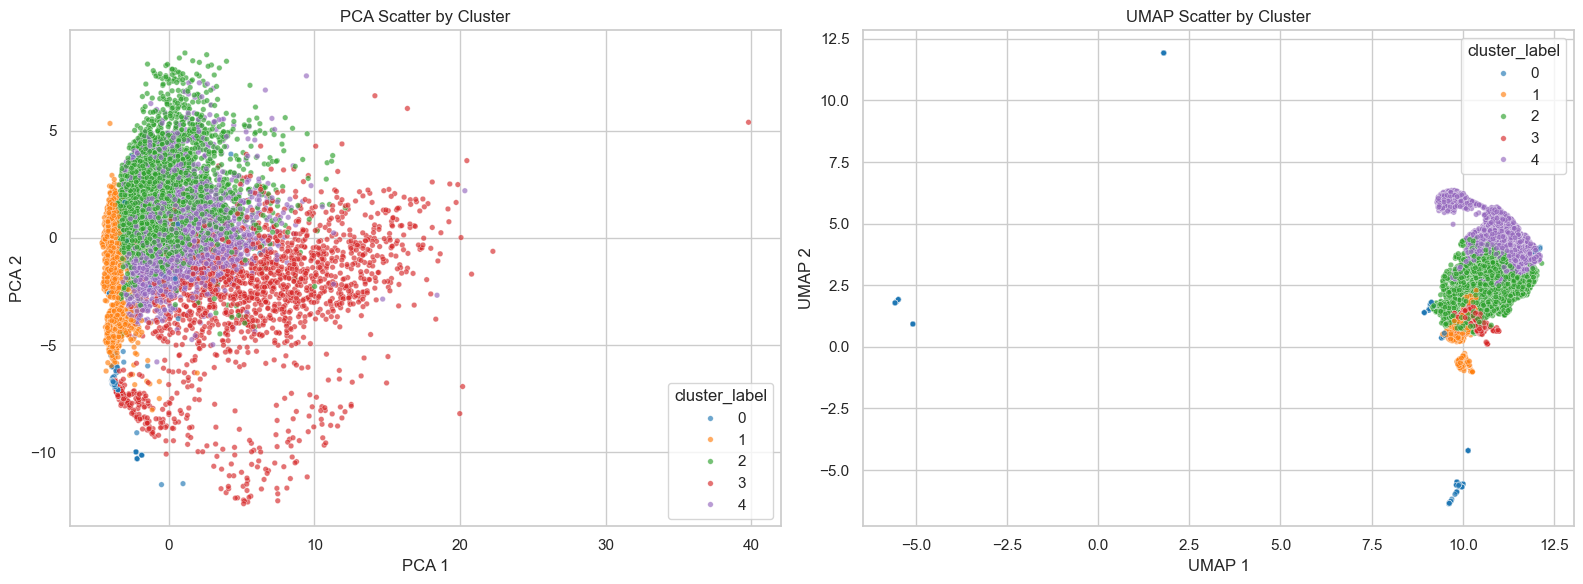

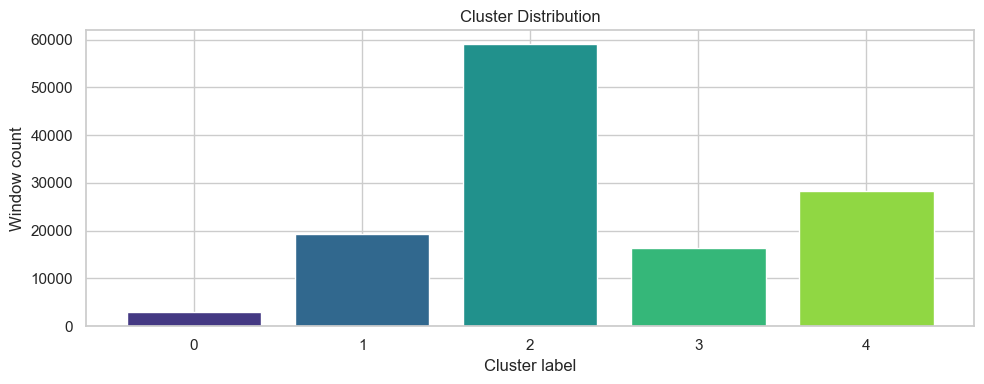

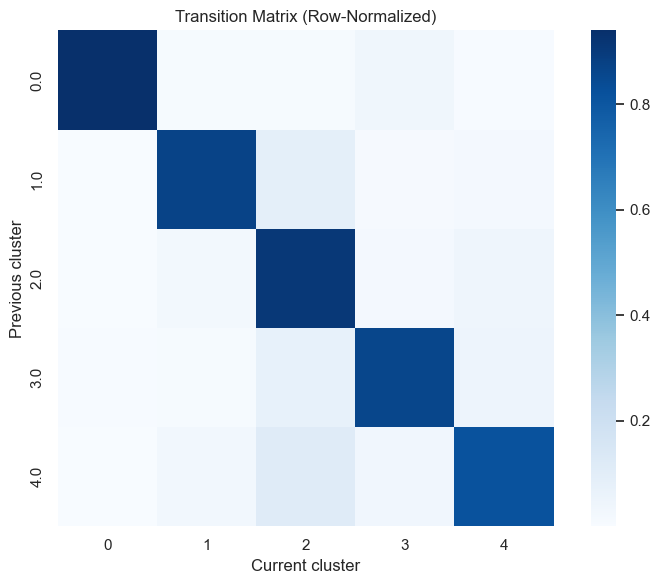

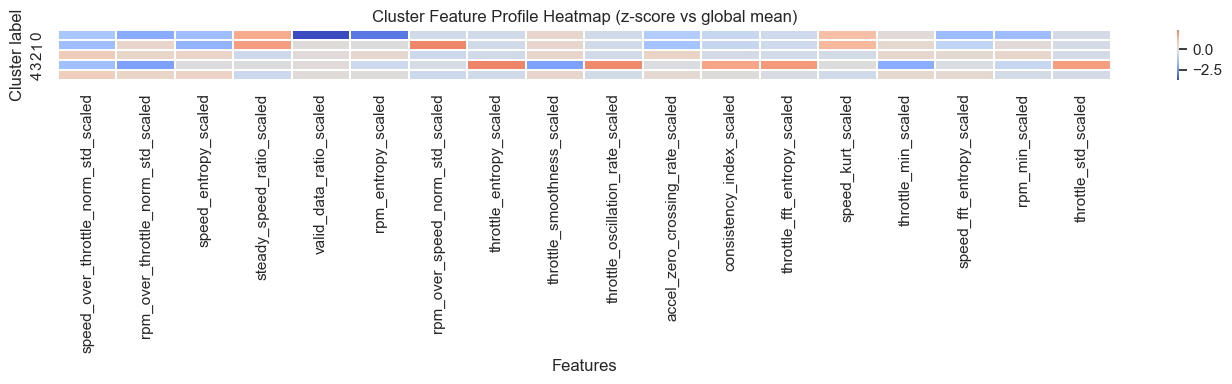

Cluster profile summaries:
Cluster 2 (58996 windows): elevated speed_over_throttle_norm_std_scaled, accel_zero_crossing_rate_scaled, speed_entropy_scaled, rpm_over_throttle_norm_std_scaled; reduced rpm_over_speed_norm_std_scaled, steady_speed_ratio_scaled, coolant_temp_std_scaled, throttle_entropy_scaled
Cluster 4 (28270 windows): elevated count_hard_braking_scaled, coolant_temp_std_scaled, negative_acceleration_ratio_scaled, speed_over_throttle_norm_std_scaled; reduced accel_min_scaled, accel_mean_scaled, jerk_mean_scaled, coolant_temp_kurt_scaled
Cluster 1 (19324 windows): elevated rpm_over_speed_norm_std_scaled, steady_speed_ratio_scaled, speed_kurt_scaled, speed_std_scaled; reduced speed_entropy_scaled, speed_over_throttle_norm_std_scaled, accel_zero_crossing_rate_scaled, accel_std_scaled
Cluster 3 (16321 windows): elevated throttle_entropy_scaled, throttle_oscillation_rate_scaled, throttle_fft_entropy_scaled, throttle_std_scaled; reduced rpm_over_throttle_norm_std_scaled, throttle

In [11]:
# Validation guardrails.
assert context_labels[["trip_id", "window_id", "cluster_label"]].isna().sum().sum() == 0
assert context_labels["cluster_label"].nunique() > 1, "Clustering collapsed to a single label."
assert set(["trip_id", "window_id", "cluster_label"]).issubset(context_labels.columns)
assert not any(column in feature_columns for column in ["trip_id", "window_id"])
assert np.isfinite(X_scaled).all()

plot_sample_size = min(12000, len(clean_df))
plot_idx = balance_sample(clean_df, plot_sample_size).index.to_numpy()
plot_df = clean_df.loc[plot_idx, ["trip_id", "window_id", "cluster_label"]].copy()
plot_df["pca_1"] = X_pca_2d[plot_idx, 0]
plot_df["pca_2"] = X_pca_2d[plot_idx, 1]
plot_df["umap_1"] = X_umap_2d[plot_idx, 0]
plot_df["umap_2"] = X_umap_2d[plot_idx, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=plot_df,
    x="pca_1",
    y="pca_2",
    hue="cluster_label",
    palette="tab10",
    s=16,
    alpha=0.65,
    ax=axes[0],
    legend=True,
)
axes[0].set_title("PCA Scatter by Cluster")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

sns.scatterplot(
    data=plot_df,
    x="umap_1",
    y="umap_2",
    hue="cluster_label",
    palette="tab10",
    s=16,
    alpha=0.65,
    ax=axes[1],
    legend=True,
)
axes[1].set_title("UMAP Scatter by Cluster")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

cluster_counts = context_labels["cluster_label"].value_counts().sort_index()
plt.figure(figsize=(10, 4))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color=sns.color_palette("viridis", len(cluster_counts)))
plt.title("Cluster Distribution")
plt.xlabel("Cluster label")
plt.ylabel("Window count")
plt.tight_layout()
plt.show()
if 'transition_matrix' in globals() and isinstance(transition_matrix, pd.DataFrame) and not transition_matrix.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(transition_matrix, cmap="Blues", annot=False, square=True)
    plt.title("Transition Matrix (Row-Normalized)")
    plt.xlabel("Current cluster")
    plt.ylabel("Previous cluster")
    plt.tight_layout()
    plt.show()

cluster_means = clean_df.groupby("cluster_label")[feature_columns].mean()
global_means = clean_df[feature_columns].mean()
global_stds = clean_df[feature_columns].std().replace(0, np.nan)
z_table = (cluster_means - global_means) / global_stds
top_feature_order = z_table.abs().mean(axis=0).sort_values(ascending=False).head(18).index

plt.figure(figsize=(14, max(4, 0.4 * len(z_table))))
sns.heatmap(z_table[top_feature_order], cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Cluster Feature Profile Heatmap (z-score vs global mean)")
plt.xlabel("Features")
plt.ylabel("Cluster label")
plt.tight_layout()
plt.show()

print("Cluster profile summaries:")
for _, row in profile_df.iterrows():
    summary = row["data_driven_summary"]
    summary = summary if summary else "No clear top deviations were isolated."
    print(f"Cluster {int(row['cluster_label'])} ({int(row['windows'])} windows): {summary}")

## 7. Validation, Reconstruction Error, and MLOps Artifacts

The notebook finishes by saving reproducible artifacts, logging metrics, and exposing the reconstruction error as an unsupervised anomaly proxy.

In [ ]:
total_runtime_seconds = time.perf_counter() - GLOBAL_START
numeric_final = clean_df[["cluster_label", "cluster_label_smoothed", "context_confidence_score", "cluster_confidence", "cluster_uncertainty", "reconstruction_error"]]
if numeric_final.isna().any().any():
    raise ValueError("Final dataset contains NaNs in critical output columns.")
if not np.isfinite(numeric_final.to_numpy()).all():
    raise ValueError("Final dataset contains non-finite values in critical output columns.")
if context_labels['cluster_label'].nunique() <= 1:
    raise ValueError("Clustering collapsed to a single cluster.")
if not clean_df['context_confidence_score'].between(0, 1).all():
    raise ValueError("Context confidence scores must be normalized to [0, 1].")
if not clean_df['cluster_confidence'].between(0, 1).all():
    raise ValueError("Cluster confidence scores must be normalized to [0, 1].")
if not clean_df['cluster_uncertainty'].between(0, 1).all():
    raise ValueError("Cluster uncertainty scores must be normalized to [0, 1].")
if not (0.01 <= anomaly_ratio <= 0.15):
    raise ValueError("Anomaly ratio is outside the expected 5% tail band.")

selected_metrics = {
    "best_embedding": best_embedding_name,
    "best_model": best_model_name,
    "best_parameter": best_row["parameter"],
    "n_clusters": int(best_row["n_clusters"]),
    "noise_ratio": float(best_row["noise_ratio"]),
    "silhouette": float(best_row["silhouette"]),
    "davies_bouldin": float(best_row["davies_bouldin"]),
    "calinski_harabasz": float(best_row["calinski_harabasz"]),
    "stability_score": float(cluster_stability_score),
    "transition_score": float(transition_score),
    "anomaly_ratio": float(anomaly_ratio),
    "rows": int(len(clean_df)),
    "features": int(len(feature_columns)),
    "pca_components": int(X_pca_full.shape[1]),
    "umap_components": int(X_umap_full.shape[1]),
    "latent_dim": int(X_ae_full.shape[1]),
    "total_runtime_seconds": float(total_runtime_seconds),
    "reconstruction_error_mean": float(clean_df["reconstruction_error"].mean()),
    "reconstruction_error_std": float(clean_df["reconstruction_error"].std()),
    "final_confidence_mean": float(clean_df["context_confidence_score"].mean()),
    "final_confidence_std": float(clean_df["context_confidence_score"].std()),
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(selected_metrics, f, indent=2)

print(f"Metrics saved to: {METRICS_PATH}")
print(f"Total runtime (sec): {total_runtime_seconds:.2f}")
print("Final label file preview:")
display(context_labels.head())
print("Validation checks passed:")
print(f"- cluster labels: {context_labels['cluster_label'].nunique()} unique values")
print(f"- transition score: {transition_score:.6f}")
print(f"- stability score: {cluster_stability_score:.6f}")
print(f"- anomaly ratio: {anomaly_ratio:.2%}")
print(f"- reconstruction error mean: {clean_df['reconstruction_error'].mean():.6f}")
print(f"- model artifacts saved under: {MODEL_DIR}")

Metrics saved to: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\context_discovery\context_discovery_metrics.json
Total runtime (sec): 770.16
Final label file preview:


,trip_id,window_id,cluster_label
0,1,0,3
1,1,1,3
2,1,2,3
3,1,3,3
4,1,4,3


Validation checks passed:
- cluster labels: 5 unique values
- transition score: 0.120265
- stability score: 0.670171
- anomaly ratio: 5.00%
- reconstruction error mean: 0.052484
- model artifacts saved under: C:\Users\mhasa\Downloads\TY PROJECT - 2\driver-behavior-ml\models\context_discovery


: 